# Necessities

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# ----
sns.set_theme(
    style="ticks",
    palette="deep",
    font_scale=1.1,
    rc={
        'figure.figsize': (12, 9),
        'figure.facecolor': 'white',
        'axes.spines.right': False,
        'axes.spines.top': False,
        'grid.alpha': 0.3,
        'axes.grid': True,
    }
    )
# ----
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("/kaggle/input/datasets/jayjoshi37/customer-subscription-churn-and-usage-patterns/customer_subscription_churn_usage_patterns.csv")
df.head()

,user_id,signup_date,plan_type,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago,churn
0,1,2023-04-15,Premium,699,1.1,4,1,8,14,Yes
1,2,2023-08-27,Premium,699,2.6,6,0,35,1,Yes
2,3,2023-10-12,Premium,699,14.3,8,3,2,14,Yes
3,4,2023-12-11,Basic,199,17.6,5,2,11,9,Yes
4,5,2023-02-14,Basic,199,9.8,5,2,6,38,Yes


In [42]:
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Missing values:\n{df.isnull().sum()}")
print(f"Churn distribution:\n{df['churn'].value_counts(normalize=True)}")

Shape: (2800, 10)
Columns: ['user_id', 'signup_date', 'plan_type', 'monthly_fee', 'avg_weekly_usage_hours', 'support_tickets', 'payment_failures', 'tenure_months', 'last_login_days_ago', 'churn']
Missing values:
user_id                   0
signup_date               0
plan_type                 0
monthly_fee               0
avg_weekly_usage_hours    0
support_tickets           0
payment_failures          0
tenure_months             0
last_login_days_ago       0
churn                     0
dtype: int64
Churn distribution:
churn
Yes    0.573214
No     0.426786
Name: proportion, dtype: float64


****
****

# Data Cleaning

In [4]:
def data_check(df, name=''):
    print("-"*20)
    print(f"Checking: {name} Data.")
    print("-"*20)

    
    print(f"{"#"*10} {name}: Null Values {"#"*10}")
    print(df.isnull().sum())
    print("-"*20)

    
    print(f"{"#"*10} {name}: Duplicates Values {"#"*10}")
    print(f"Duplicates Count: {df.duplicated().sum()}")
    print("-"*20)

    
    print(f"{"#"*10} {name}: Data Types {"#"*10}")
    print(df.dtypes)
    print("-"*20)

    
    print(f"{"#"*10} {name}: Outliers (Describe) {"#"*10}")
    print(df.describe())
    print("-"*20)

In [5]:
data_check(df,'Customer Subscription dataset')

--------------------
Checking: Customer Subscription dataset Data.
--------------------
########## Customer Subscription dataset: Null Values ##########
user_id                   0
signup_date               0
plan_type                 0
monthly_fee               0
avg_weekly_usage_hours    0
support_tickets           0
payment_failures          0
tenure_months             0
last_login_days_ago       0
churn                     0
dtype: int64
--------------------
########## Customer Subscription dataset: Duplicates Values ##########
Duplicates Count: 0
--------------------
########## Customer Subscription dataset: Data Types ##########
user_id                     int64
signup_date                object
plan_type                  object
monthly_fee                 int64
avg_weekly_usage_hours    float64
support_tickets             int64
payment_failures            int64
tenure_months               int64
last_login_days_ago         int64
churn                      object
dtype: object
---

In [6]:
df['signup_date'] = pd.to_datetime(df['signup_date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   user_id                 2800 non-null   int64         
 1   signup_date             2800 non-null   datetime64[ns]
 2   plan_type               2800 non-null   object        
 3   monthly_fee             2800 non-null   int64         
 4   avg_weekly_usage_hours  2800 non-null   float64       
 5   support_tickets         2800 non-null   int64         
 6   payment_failures        2800 non-null   int64         
 7   tenure_months           2800 non-null   int64         
 8   last_login_days_ago     2800 non-null   int64         
 9   churn                   2800 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(6), object(2)
memory usage: 218.9+ KB


**Clean Dataset**

****
****

# Analysis

## What is our overall churn rate, and how does it vary by plan type? 

### Overall Churn Rate

In [7]:
round(df['churn'].value_counts(normalize=True)*100,2)

churn
Yes    57.32
No     42.68
Name: proportion, dtype: float64

* **57.32% Overall Churn Rate**

In [44]:
# Is this monthly or annual churn? Check tenure distribution
print(f"Avg. tenure: {df['tenure_months'].mean():.1f} months")
print(f"Median tenure: {df['tenure_months'].median():.1f} months")

Avg. tenure: 18.6 months
Median tenure: 18.0 months


****

### Churn Rate by Plan

In [8]:
plan_churn = df.groupby(["plan_type","churn"])['user_id'].count().reset_index()

plan_churn = plan_churn.rename(columns={'user_id': 'count'})

plan_churn['plan_total'] = plan_churn.groupby('plan_type')['count'].transform('sum')

plan_churn['churn_rate'] = round((plan_churn['count'] / plan_churn['plan_total'])*100,2)

plan_churn= plan_churn[plan_churn['churn']=='Yes']

plan_churn = plan_churn.sort_values(by='churn_rate', ascending=False)

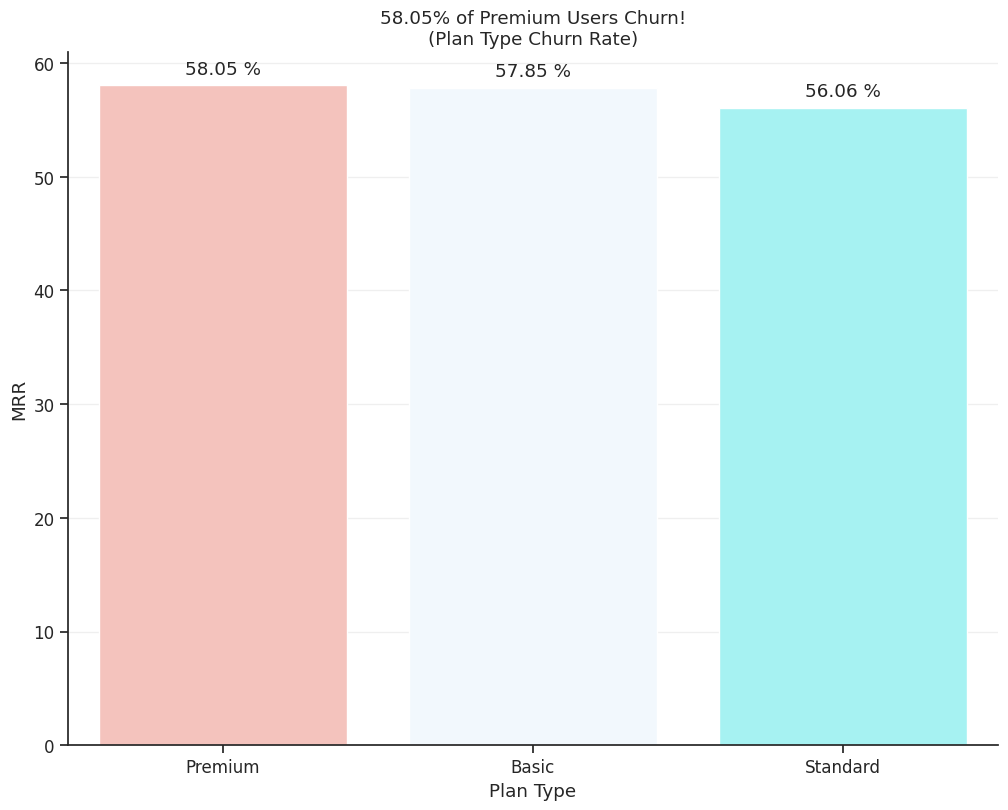

In [9]:
ax= sns.barplot(plan_churn, x='plan_type',y='churn_rate',hue='plan_type',palette=['#FDBCB4','#F0F8FF','#99FFFF'])

for i, v in enumerate(plan_churn['churn_rate']):
    ax.text(i, v+1, f"{v:,.2f} %", ha='center')

plt.ylabel("MRR")
plt.xlabel("Plan Type")

plt.title('58.05% of Premium Users Churn!\n(Plan Type Churn Rate)')

plt.savefig('Plan_Type_Churn_Rate.png')

**Standard Plan Type Score The Lowest Churn Rate with 56.06% While Premium Plan Type Score 58.08%, and basic fall in between with 57.85%**

In [10]:
print(plan_churn[['plan_type','churn_rate']])

  plan_type  churn_rate
3   Premium       58.05
1     Basic       57.85
5  Standard       56.06


****

### MRR *(Monthly Recurring Revenue)*

In [11]:
df[df['churn']=='No']['monthly_fee'].sum()

np.int64(517805)

In [12]:
plan_mrr = df.groupby(["plan_type","churn"])['monthly_fee'].sum().reset_index()

plan_mrr = plan_mrr.rename(columns={'monthly_fee': 'monthly_revenue'})

plan_mrr= plan_mrr[plan_mrr['churn']=='No']

plan_mrr['plan_mrr'] = plan_mrr.groupby('plan_type')['monthly_revenue'].transform('sum')

plan_mrr['total_mrr'] = plan_mrr['monthly_revenue'].sum()

plan_mrr['plan_mrr_pct'] = round((plan_mrr['plan_mrr'] / plan_mrr['total_mrr'])*100,2)
plan_mrr=plan_mrr.sort_values(by='plan_mrr_pct', ascending=False)

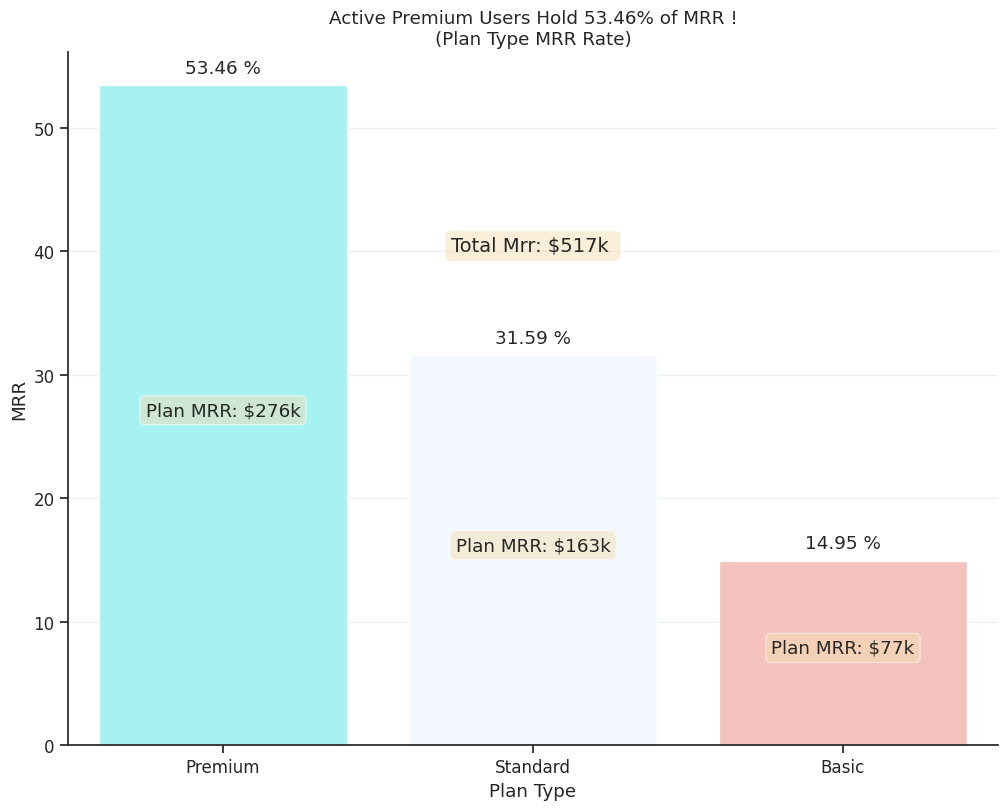

In [13]:
ax= sns.barplot(plan_mrr, x='plan_type',y='plan_mrr_pct',hue='plan_type',palette=['#99FFFF','#F0F8FF','#FDBCB4'])
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

for i, v in enumerate(plan_mrr['plan_mrr_pct']):
    ax.text(i, v+1, f"{v:,.2f} %", ha='center')

for i, v in enumerate(plan_mrr['plan_mrr_pct']):
    ax.text(i, v/2, f"Plan MRR: ${int(v*plan_mrr['total_mrr'][0]/100000)}k", ha='center',bbox=props)
    

ax.text(1, 40, f"Total Mrr: ${int(plan_mrr['total_mrr'][0]/1000)}k ", ha='center',fontsize=14, bbox=props)

plt.ylabel("MRR")
plt.xlabel("Plan Type")

plt.title('Active Premium Users Hold 53.46% of MRR !\n(Plan Type MRR Rate)')

plt.savefig('Plan_Type_mrr_pct.png')

**Premium Users Hold 53.46% (USD 276k) of total MRR (USD 517k), while basic users hold 14.95% (USD 77k) and standard users hold 31.59% (USD 163k)**

****

In [18]:
lost_revenue = df.groupby(["plan_type","churn"])['monthly_fee'].sum().reset_index()

lost_revenue = lost_revenue.rename(columns={'monthly_fee': 'monthly_revenue'})

lost_revenue= lost_revenue[lost_revenue['churn']=='Yes']

lost_revenue['plan_revenue'] = lost_revenue.groupby('plan_type')['monthly_revenue'].transform('sum')

lost_revenue['total_revenue'] = lost_revenue['monthly_revenue'].sum()

lost_revenue['plan_revenue_pct'] = round((lost_revenue['plan_revenue'] / lost_revenue['total_revenue'])*100,2)
lost_revenue=lost_revenue.sort_values(by='plan_revenue_pct', ascending=False)

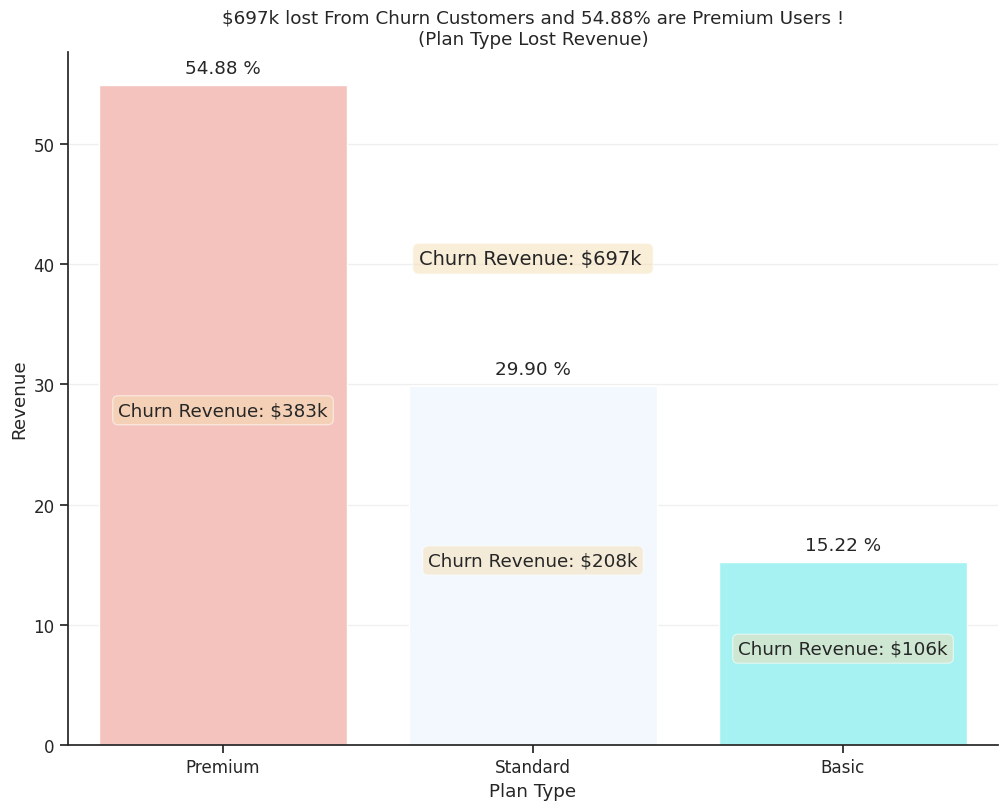

In [34]:
ax= sns.barplot(lost_revenue, x='plan_type',y='plan_revenue_pct',hue='plan_type',palette=['#FDBCB4','#F0F8FF','#99FFFF'])
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

for i, v in enumerate(lost_revenue['plan_revenue_pct']):
    ax.text(i, v+1, f"{v:,.2f} %", ha='center')

for i, v in enumerate(lost_revenue['plan_revenue_pct']):
    ax.text(i, v/2, f"Churn Revenue: ${int(v*lost_revenue['total_revenue'][1]/100000)}k", ha='center',bbox=props)
    

ax.text(1, 40, f"Churn Revenue: ${int(lost_revenue['total_revenue'][1]/1000)}k ", ha='center',fontsize=14, bbox=props)

plt.ylabel("Revenue")
plt.xlabel("Plan Type")

plt.title('$697k lost From Churn Customers and 54.88% are Premium Users !\n(Plan Type Lost Revenue)')

plt.savefig('Plan_Type_lost_revenue.png')

**Premium Users Hold 54.88% (USD 383k) of total Lost Revenue By Churn (USD 697k), while basic users hold 15.22% (USD 106k) and standard users hold 29.9% (USD 208k)**

****

### Plan Distribution

In [35]:
df.head()

,user_id,signup_date,plan_type,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago,churn
0,1,2023-04-15,Premium,699,1.1,4,1,8,14,Yes
1,2,2023-08-27,Premium,699,2.6,6,0,35,1,Yes
2,3,2023-10-12,Premium,699,14.3,8,3,2,14,Yes
3,4,2023-12-11,Basic,199,17.6,5,2,11,9,Yes
4,5,2023-02-14,Basic,199,9.8,5,2,6,38,Yes


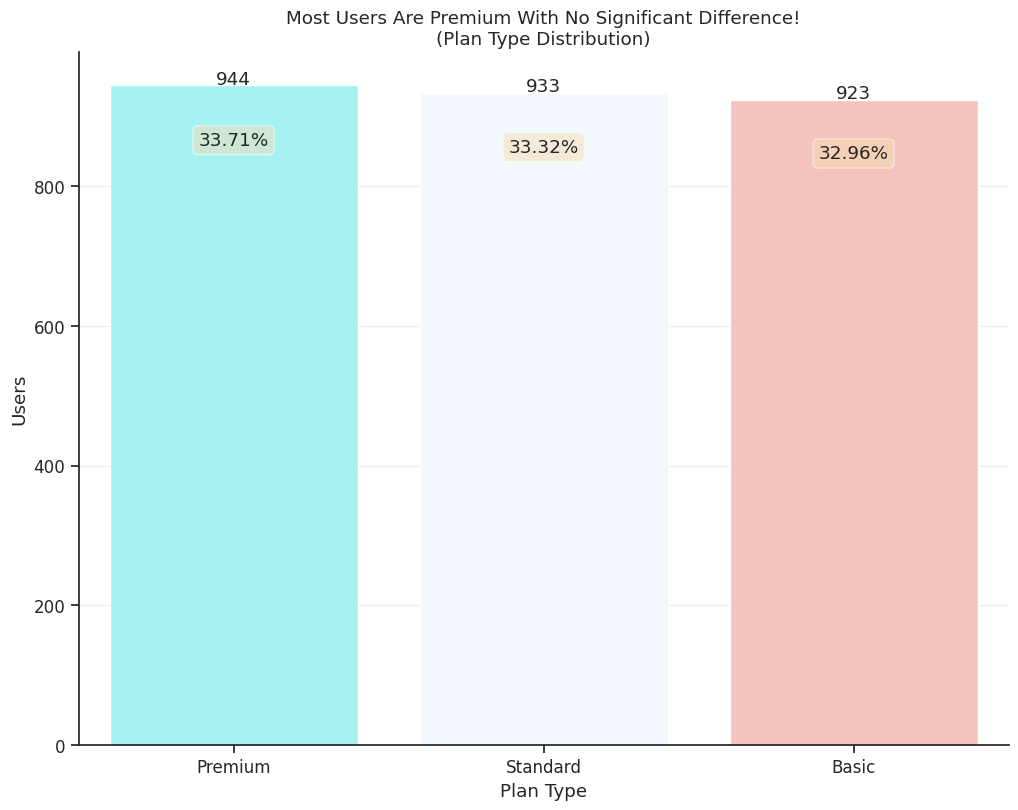

In [40]:
plan_churn=plan_churn.sort_values(by='plan_total', ascending=False)
ax= sns.barplot(plan_churn, x='plan_type',y='plan_total',hue='plan_type',palette=['#99FFFF','#F0F8FF','#FDBCB4'])
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

for i, v in enumerate(plan_churn['plan_total']):
    ax.text(i, v+2, f"{v}", ha='center')

for i, v in enumerate(plan_churn['plan_total']):
    ax.text(i, v/1.1, f"{round((v/sum(plan_churn['plan_total'])*100),2)}%", ha='center', bbox=props)
    
plt.ylabel("Users")
plt.xlabel("Plan Type")

plt.title('Most Users Are Premium With No Significant Difference!\n(Plan Type Distribution)')

plt.savefig('Plan_Type_dist.png')

**944 Premium Users (33.71% of total Users), 933 Standard Users (33.32%), 923 Basic Users (32.96%)**

In [45]:
from scipy import stats

# Chi-square test for churn by plan
contingency = pd.crosstab(df['plan_type'], df['churn'])
chi2, p, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-square p-value: {p:.4f}")
if p < 0.05:
    print("Churn differences by plan are statistically significant")
else:
    print("Churn differences by plan may be random variation")

Chi-square p-value: 0.6301
Churn differences by plan may be random variation


****

### Payment Failure Churn

In [49]:
# Churn rate by payment failure status
payment_churn = df.groupby('payment_failures')['churn'].apply(lambda x: (x == 'Yes').mean()).reset_index()
print("Churn rate by payment failures:")
print(payment_churn)

# Revenue at risk from payment failures
at_risk_mrr = df[df['payment_failures'] > 0]['monthly_fee'].sum()
print(f"\nMRR at risk from payment failures: ${at_risk_mrr:,.0f}")


Churn rate by payment failures:
   payment_failures     churn
0                 0  0.395928
1                 1  0.401210
2                 2  0.642259
3                 3  0.670913
4                 4  0.664459
5                 5  0.667391

MRR at risk from payment failures: $1,024,842


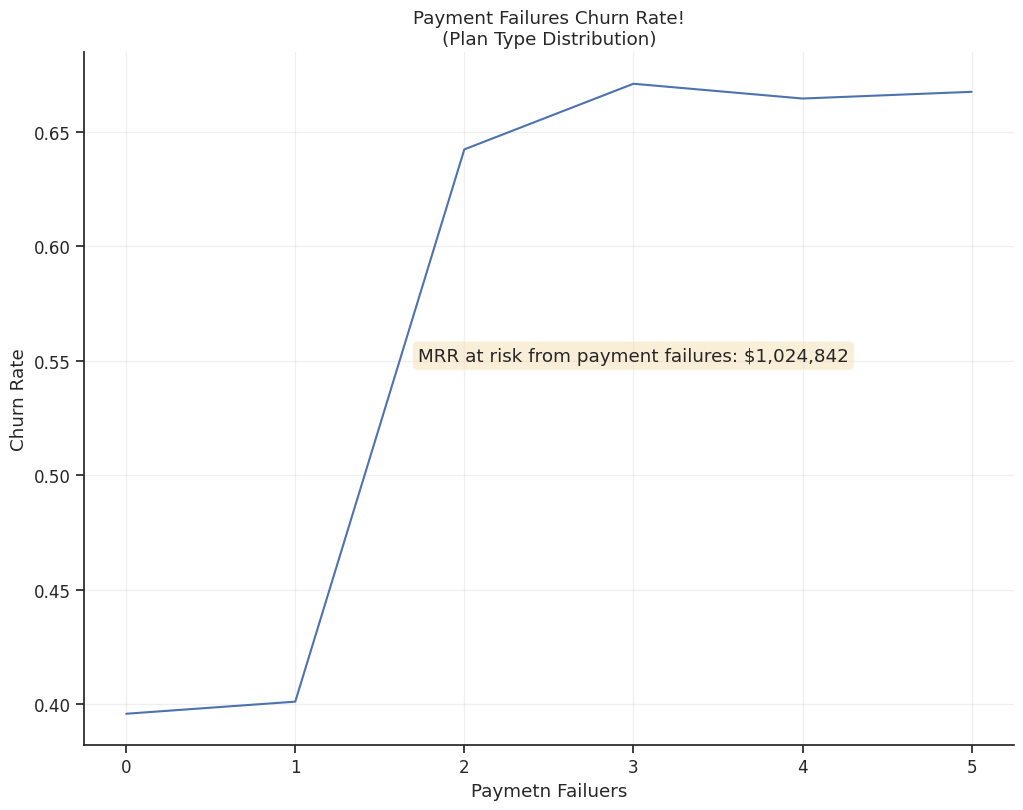

In [58]:
ax= sns.lineplot(payment_churn, x='payment_failures',y='churn')

ax.text(3, 0.55, f"MRR at risk from payment failures: $1,024,842", ha='center', bbox=props)
    
plt.ylabel("Churn Rate")
plt.xlabel("Paymetn Failuers")

plt.title('Payment Failures Churn Rate!\n(Plan Type Distribution)')

plt.savefig('Payment_Failures_churn_rate.png')

In [59]:
# Identify "at-risk but salvageable" customers
at_risk_active = df[(df['payment_failures'] >= 2) & (df['churn'] == 'No')]

# Calculate MRR
at_risk_mrr = at_risk_active['monthly_fee'].sum()
at_risk_count = len(at_risk_active)

print(f"At-risk active customers: {at_risk_count:,}")
print(f"MRR at risk (salvageable): ${at_risk_mrr:,.0f}")

# Model intervention impact
reduction_scenarios = [0.20, 0.30, 0.50]  # 20%, 30%, 50% churn reduction
for scenario in reduction_scenarios:
    recovered_mrr = at_risk_mrr * scenario
    print(f"If we reduce payment-failure churn by {scenario*100:.0f}%: +${recovered_mrr:,.0f} MRR recovered")

At-risk active customers: 631
MRR at risk (salvageable): $270,569
If we reduce payment-failure churn by 20%: +$54,114 MRR recovered
If we reduce payment-failure churn by 30%: +$81,171 MRR recovered
If we reduce payment-failure churn by 50%: +$135,284 MRR recovered


****

### LTV by Plan + LTV:CAC Ratio

In [60]:
# Assumptions
GROSS_MARGIN = 0.80  # Typical for SaaS
CAC_MULTIPLIER = 3   # Assume CAC = 3 × monthly_fee (industry benchmark)

# Calculate LTV per customer
df['ltv'] = df['monthly_fee'] * df['tenure_months'] * GROSS_MARGIN

# Calculate CAC per customer
df['cac'] = df['monthly_fee'] * CAC_MULTIPLIER

# Calculate LTV:CAC ratio
df['ltv_cac_ratio'] = df['ltv'] / df['cac']

# Aggregate by plan
ltv_by_plan = df.groupby('plan_type').agg(
    avg_ltv=('ltv', 'mean'),
    avg_cac=('cac', 'mean'),
    avg_ltv_cac=('ltv_cac_ratio', 'mean'),
    customer_count=('user_id', 'count')
).round(2)

print("LTV:CAC by Plan:")
print(ltv_by_plan)

# Flag unsustainable plans (LTV:CAC < 3:1)
unsustainable = ltv_by_plan[ltv_by_plan['avg_ltv_cac'] < 3]
if not unsustainable.empty:
    print(f"\n⚠️ Warning: {list(unsustainable.index)} have LTV:CAC < 3:1 — review pricing or retention")

LTV:CAC by Plan:
            avg_ltv  avg_cac  avg_ltv_cac  customer_count
plan_type                                                
Basic       2923.04    597.0         4.90             923
Premium    10487.96   2097.0         5.00             944
Standard    5974.82   1197.0         4.99             933


**LTV/CAC ≥ 3:1**
Healthy unit economics

****
****